# Benchmarking on Real-World Datasets

This notebook runs the DeepBullwhip benchmarking framework across multiple well-known demand datasets:

| Dataset | Domain | Frequency | Periods | Source |
|---------|--------|-----------|---------|--------|
| **M5 Walmart** | Retail (US) | Weekly | 277 | Kaggle M5 Competition |
| **Australian PBS** | Pharmaceutical | Monthly | 197 | tidyverts/tsibbledata |
| **WSTS Semiconductor** | Electronics | Monthly | 60 | Bundled sample |
| **Beer Game** | Classic simulation | Weekly | 52 | Built-in |

We compare ordering policies (OUT, POUT, Constant) under different forecasting methods (Naive, MA) to see how bullwhip amplification varies by demand characteristics.

## 1. Load All Datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from deepbullwhip.benchmark import BenchmarkRunner
from deepbullwhip.demand.replay import ReplayDemandGenerator
from deepbullwhip.datasets.loader import load_dataset
from deepbullwhip.datasets import load_wsts, load_beer_game
from deepbullwhip.diagnostics.plots import (
    COLORS, _apply_style, DOUBLE_COL, SINGLE_COL, GOLDEN, _ECHELON_COLORS,
)

_apply_style()

# Load all datasets
datasets = {
    "M5 CA$_1$ Foods": load_dataset("m5", store="CA_1", dept="FOODS_1", freq="weekly"),
    "M5 TX$_1$ Hobbies": load_dataset("m5", store="TX_1", dept="HOBBIES_1", freq="weekly"),
    "PBS A10 (Diabetes)": load_dataset("australian_drug_sales", atc2="A10"),
    "PBS A02 (Acid)": load_dataset("australian_drug_sales", atc2="A02"),
    "WSTS Semiconductor": load_wsts("worldwide", "total"),
    "Beer Game": load_beer_game(T=52),
}

print(f"{'Dataset':<25} {'T':>5} {'Mean':>10} {'Std':>10} {'CV':>8}")
print("-" * 60)
for name, d in datasets.items():
    cv = d.std() / d.mean() if d.mean() > 0 else 0
    # Strip LaTeX for printing
    clean = name.replace("$_1$", "_1").replace("$", "")
    print(f"{clean:<25} {len(d):>5} {d.mean():>10.1f} {d.std():>10.1f} {cv:>8.3f}")

Dataset                       T       Mean        Std       CV
------------------------------------------------------------
M5 CA_1 Foods               277     2081.9      467.7    0.225
M5 TX_1 Hobbies             277     1416.7      253.9    0.179
PBS A10 (Diabetes)          197    70657.6    79491.3    1.125
PBS A02 (Acid)              197   143597.4   143703.6    1.001
WSTS Semiconductor           60       41.3        5.7    0.138
Beer Game                    52        7.6        1.2    0.155


## 2. Visualize Demand Patterns

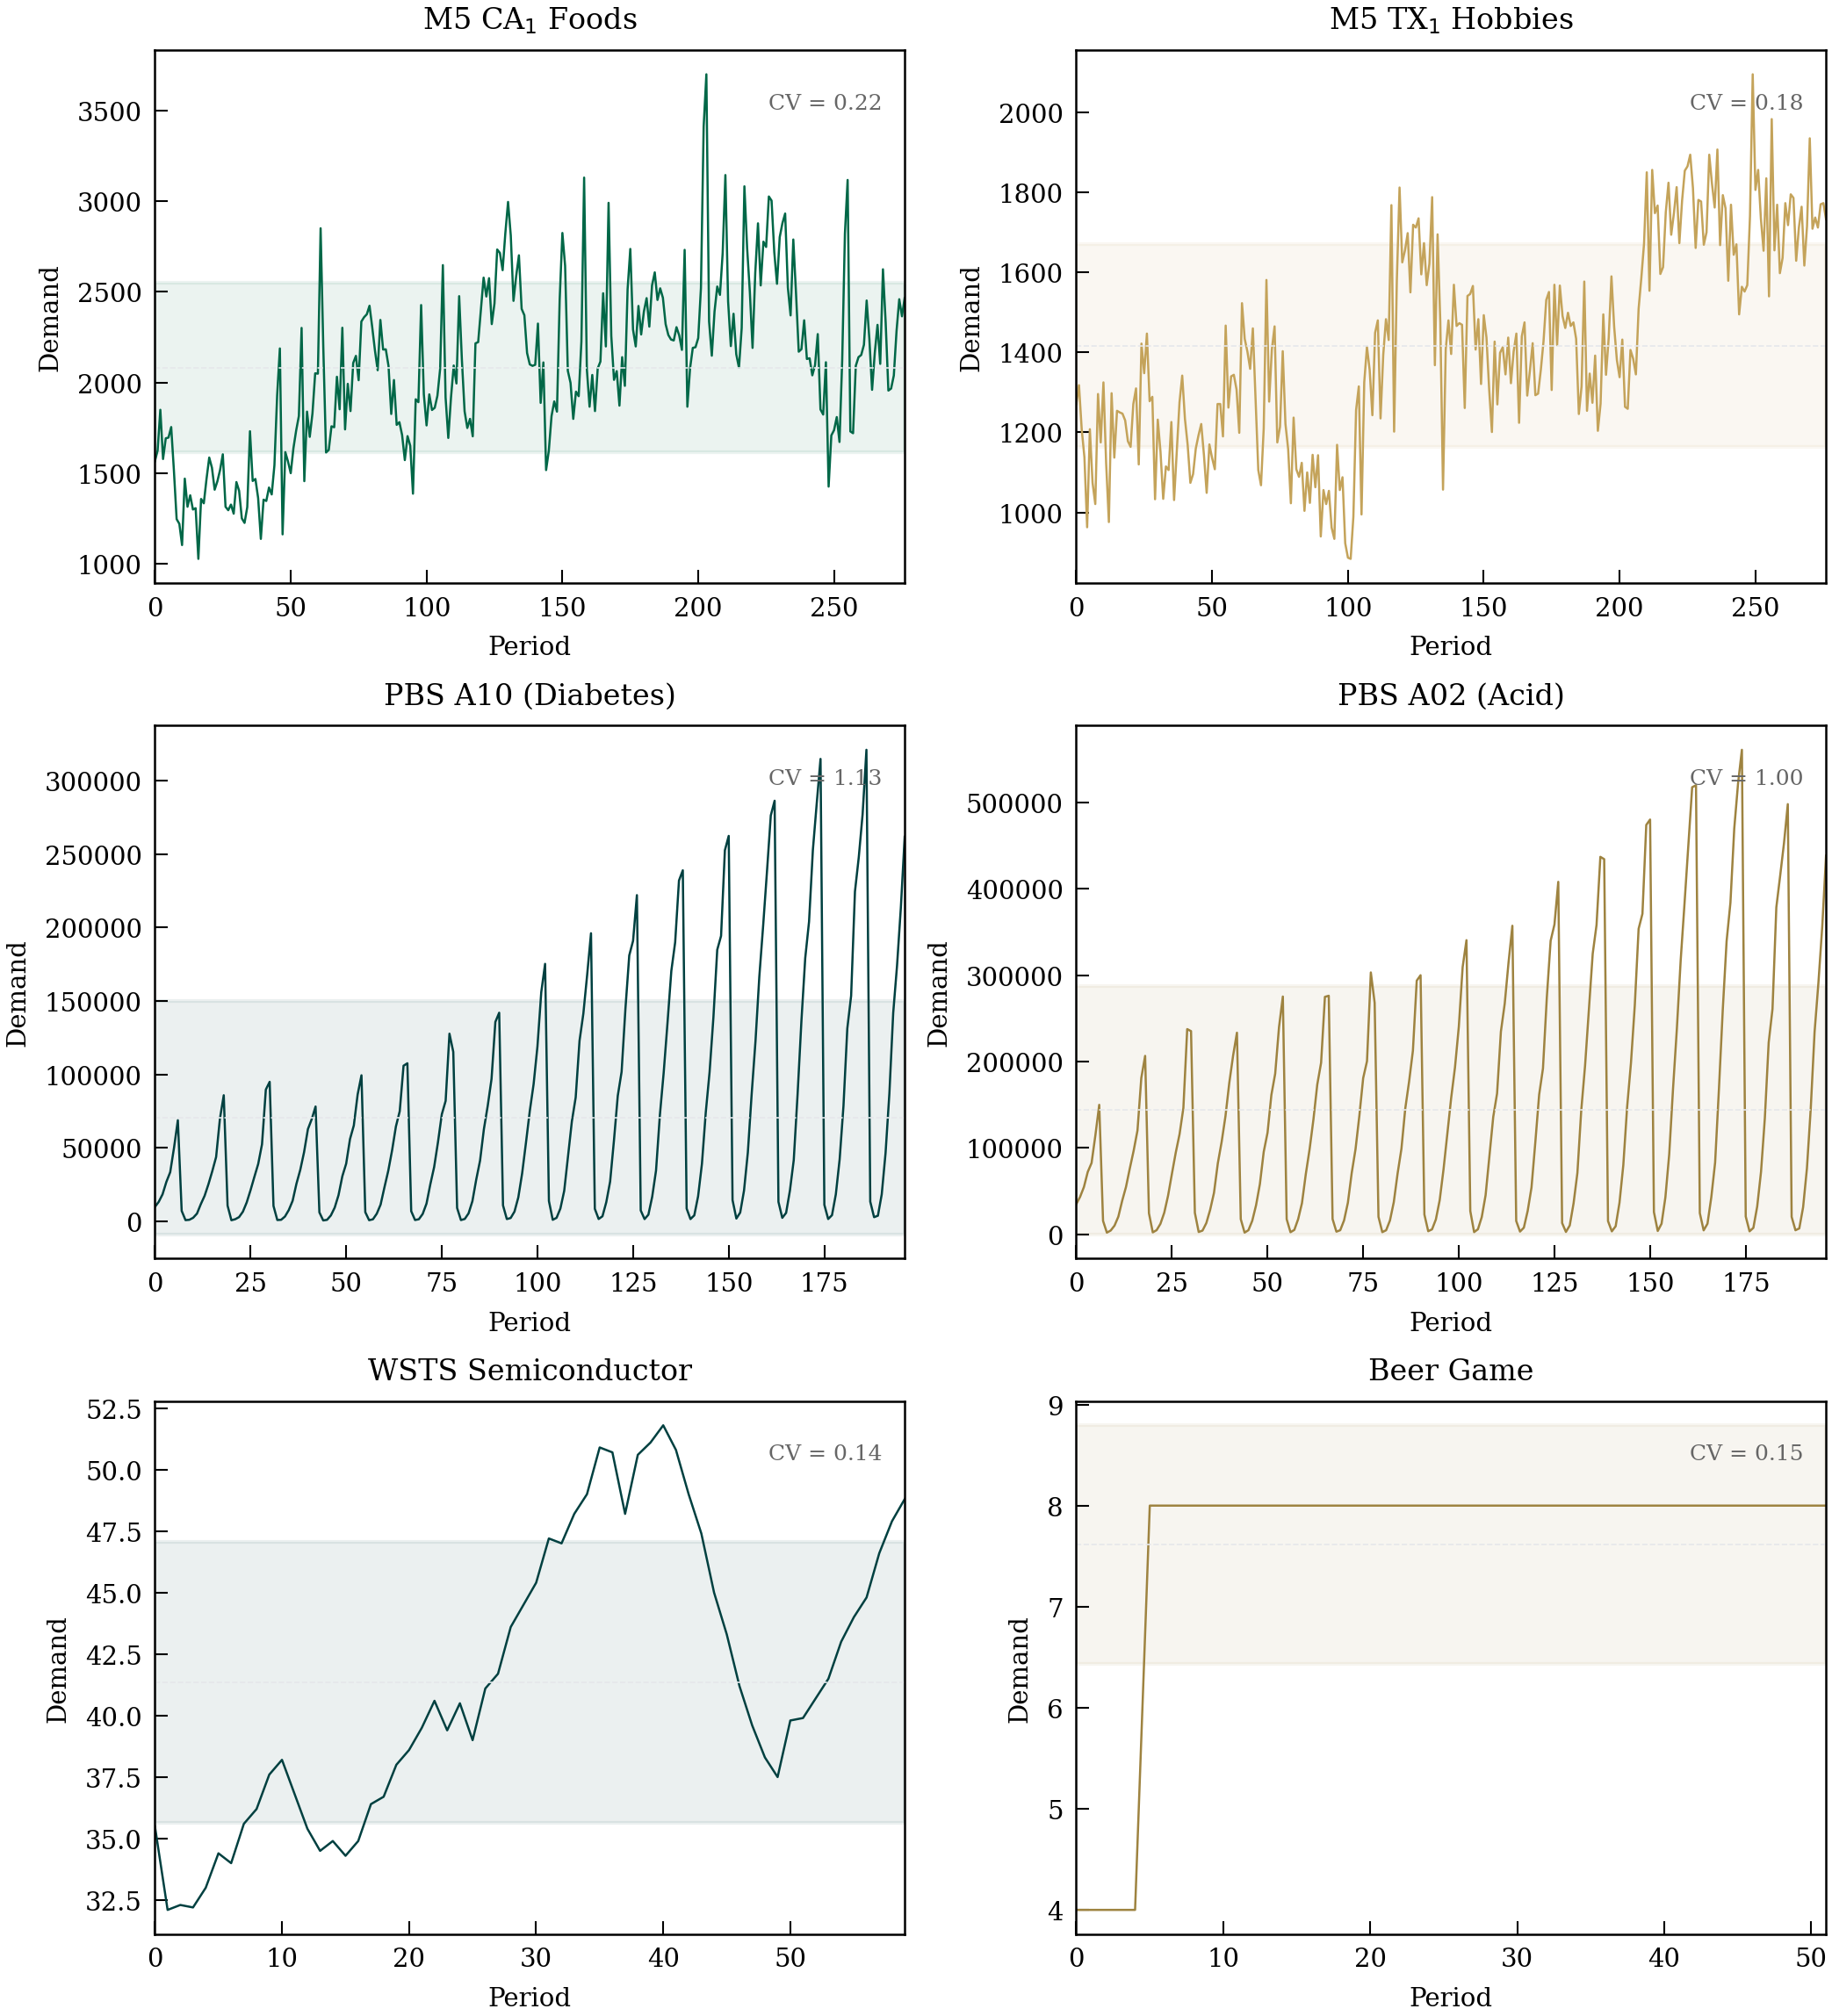

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(DOUBLE_COL, DOUBLE_COL * 1.1))
axes = axes.flatten()

ds_colors = [COLORS["E1"], COLORS["E2"], COLORS["E3"], COLORS["E4"], "#004040", "#9e8340"]

for ax, (name, d), color in zip(axes, datasets.items(), ds_colors):
    weeks = np.arange(len(d))
    mu = d.mean()
    sigma = d.std()

    ax.fill_between(weeks, mu - sigma, mu + sigma,
                     color=color, alpha=0.08)
    ax.plot(weeks, d, color=color, linewidth=0.6)
    ax.axhline(mu, color=COLORS["grid"], linestyle="--", linewidth=0.4)

    ax.set_title(name, fontsize=8)
    ax.set_xlabel("Period", fontsize=7)
    ax.set_ylabel("Demand", fontsize=7)
    ax.set_xlim(0, len(d) - 1)

    # Annotate CV in top-right corner
    cv = sigma / mu if mu > 0 else 0
    ax.text(0.97, 0.92, f"CV = {cv:.2f}", transform=ax.transAxes,
            fontsize=6, ha="right", va="top", color="#666666")

fig.savefig("dataset_demand_patterns.pdf", dpi=300, bbox_inches="tight")
fig.savefig("dataset_demand_patterns.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Run Benchmarks Across All Datasets

We run each dataset through a 2-tier consumer supply chain with 3 policies and 2 forecasters.

In [3]:
all_results = []

for ds_name, demand in datasets.items():
    gen = ReplayDemandGenerator(data=demand)

    runner = BenchmarkRunner(
        chain_config="consumer_2tier",
        demand=gen,
        T=min(len(demand), 200),
        N=10,
        seed=42,
    )

    policies = [
        "order_up_to",
        ("proportional_out", {"alpha": 0.3}),
        ("proportional_out", {"alpha": 0.7}),
        ("constant_order", {"order_quantity": float(demand.mean())}),
    ]

    df = runner.run(
        policies=policies,
        forecasters=["naive", ("moving_average", {"window": 10})],
        metrics=["BWR", "FILL_RATE", "TC"],
    )
    df["dataset"] = ds_name
    all_results.append(df)
    clean = ds_name.replace("$_1$", "_1").replace("$", "")
    print(f"  {clean}: done")

results = pd.concat(all_results, ignore_index=True)
print(f"\nTotal rows: {len(results)}")

  M5 CA_1 Foods: done
  M5 TX_1 Hobbies: done
  PBS A10 (Diabetes): done
  PBS A02 (Acid): done
  WSTS Semiconductor: done
  Beer Game: done

Total rows: 288


## 4. BWR Comparison Across Datasets (Echelon 1, Naive Forecaster)

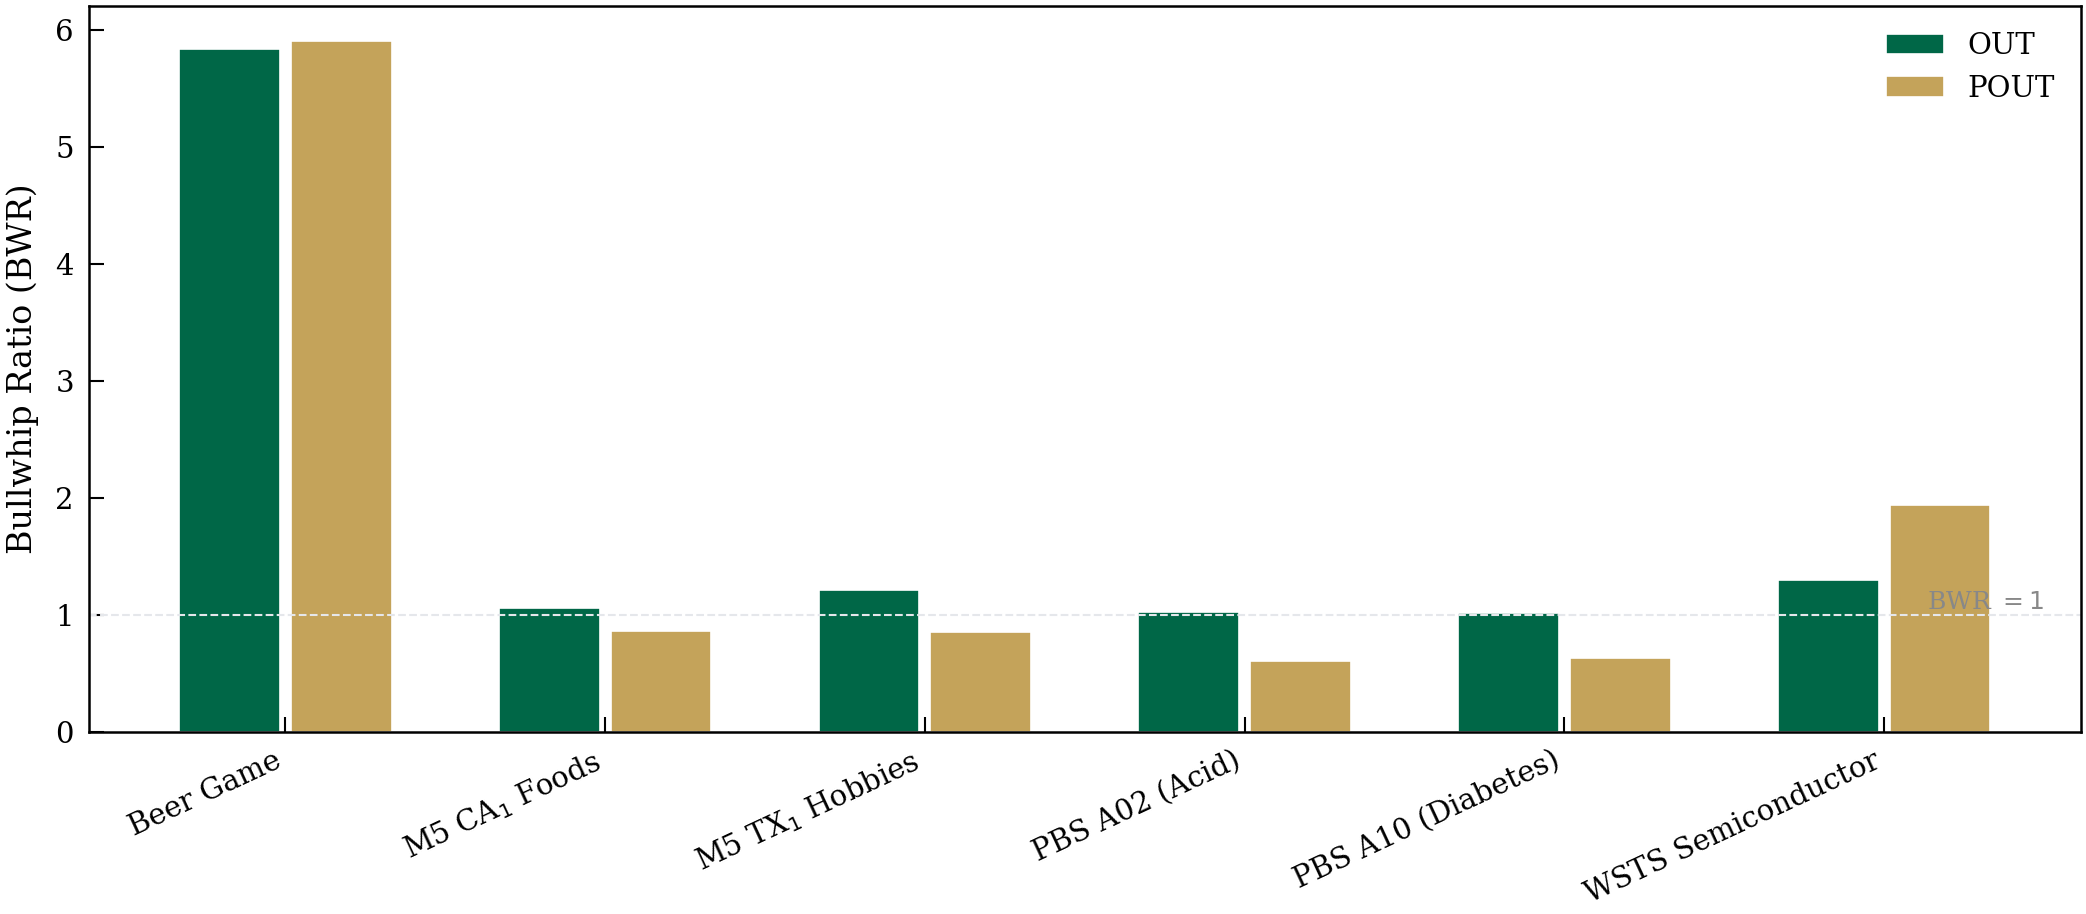

In [4]:
POLICY_LABELS = {"order_up_to": "OUT", "proportional_out": "POUT", "constant_order": "Constant"}
POLICY_COLORS_MAP = {"order_up_to": COLORS["E1"], "proportional_out": COLORS["E2"], "constant_order": COLORS["E4"]}

bwr_e1 = results[
    (results["echelon"] == "E1") &
    (results["metric"] == "BWR") &
    (results["forecaster"] == "naive") &
    (results["policy"] != "constant_order")
]

pivot_bwr = bwr_e1.pivot_table(index="dataset", columns="policy", values="value")

fig, ax = plt.subplots(figsize=(DOUBLE_COL, DOUBLE_COL / GOLDEN / 1.4))

n_datasets = len(pivot_bwr)
n_policies = len(pivot_bwr.columns)
x = np.arange(n_datasets)
bar_w = 0.7 / n_policies

for i, policy in enumerate(pivot_bwr.columns):
    offset = (i - n_policies / 2 + 0.5) * bar_w
    color = POLICY_COLORS_MAP.get(policy, _ECHELON_COLORS[i])
    label = POLICY_LABELS.get(policy, policy)
    bars = ax.bar(x + offset, pivot_bwr[policy], bar_w * 0.9,
                  color=color, edgecolor="white", linewidth=0.4, label=label)

ax.axhline(y=1.0, color=COLORS["grid"], linestyle="--", linewidth=0.5)
ax.set_ylabel("Bullwhip Ratio (BWR)")
ax.set_xticks(x)
ax.set_xticklabels(pivot_bwr.index, rotation=25, ha="right", fontsize=7)
ax.legend(frameon=False, fontsize=7)

# Annotate BWR=1 line
ax.text(len(x) - 0.5, 1.05, r"BWR $= 1$", fontsize=6, color="#888888", ha="right")

fig.savefig("bwr_across_datasets.pdf", dpi=300, bbox_inches="tight")
fig.savefig("bwr_across_datasets.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Summary Table: All Datasets x Policies (E1, Naive)

In [5]:
summary = results[
    (results["echelon"] == "E1") & (results["forecaster"] == "naive")
].pivot_table(
    index=["dataset", "policy"],
    columns="metric",
    values="value",
    aggfunc="mean",
)
print(summary.to_string(float_format="%.2f"))

metric                               BWR  FILL_RATE           TC
dataset            policy                                       
Beer Game          constant_order   0.00       1.00       534.80
                   order_up_to      5.83       0.98        63.20
                   proportional_out 5.91       0.15       347.62
M5 CA$_1$ Foods    constant_order   0.00       0.98   1062326.88
                   order_up_to      1.06       0.67     37419.72
                   proportional_out 0.86       0.10    399453.71
M5 TX$_1$ Hobbies  constant_order   0.00       0.97    598795.12
                   order_up_to      1.21       0.78     17957.35
                   proportional_out 0.85       0.07    256480.67
PBS A02 (Acid)     constant_order   0.00       0.99 120279144.83
                   order_up_to      1.02       0.68  14922249.42
                   proportional_out 0.61       0.45  28542995.42
PBS A10 (Diabetes) constant_order   0.00       0.99  82503214.20
                   order_

## 6. Forecaster Impact: Naive vs Moving Average

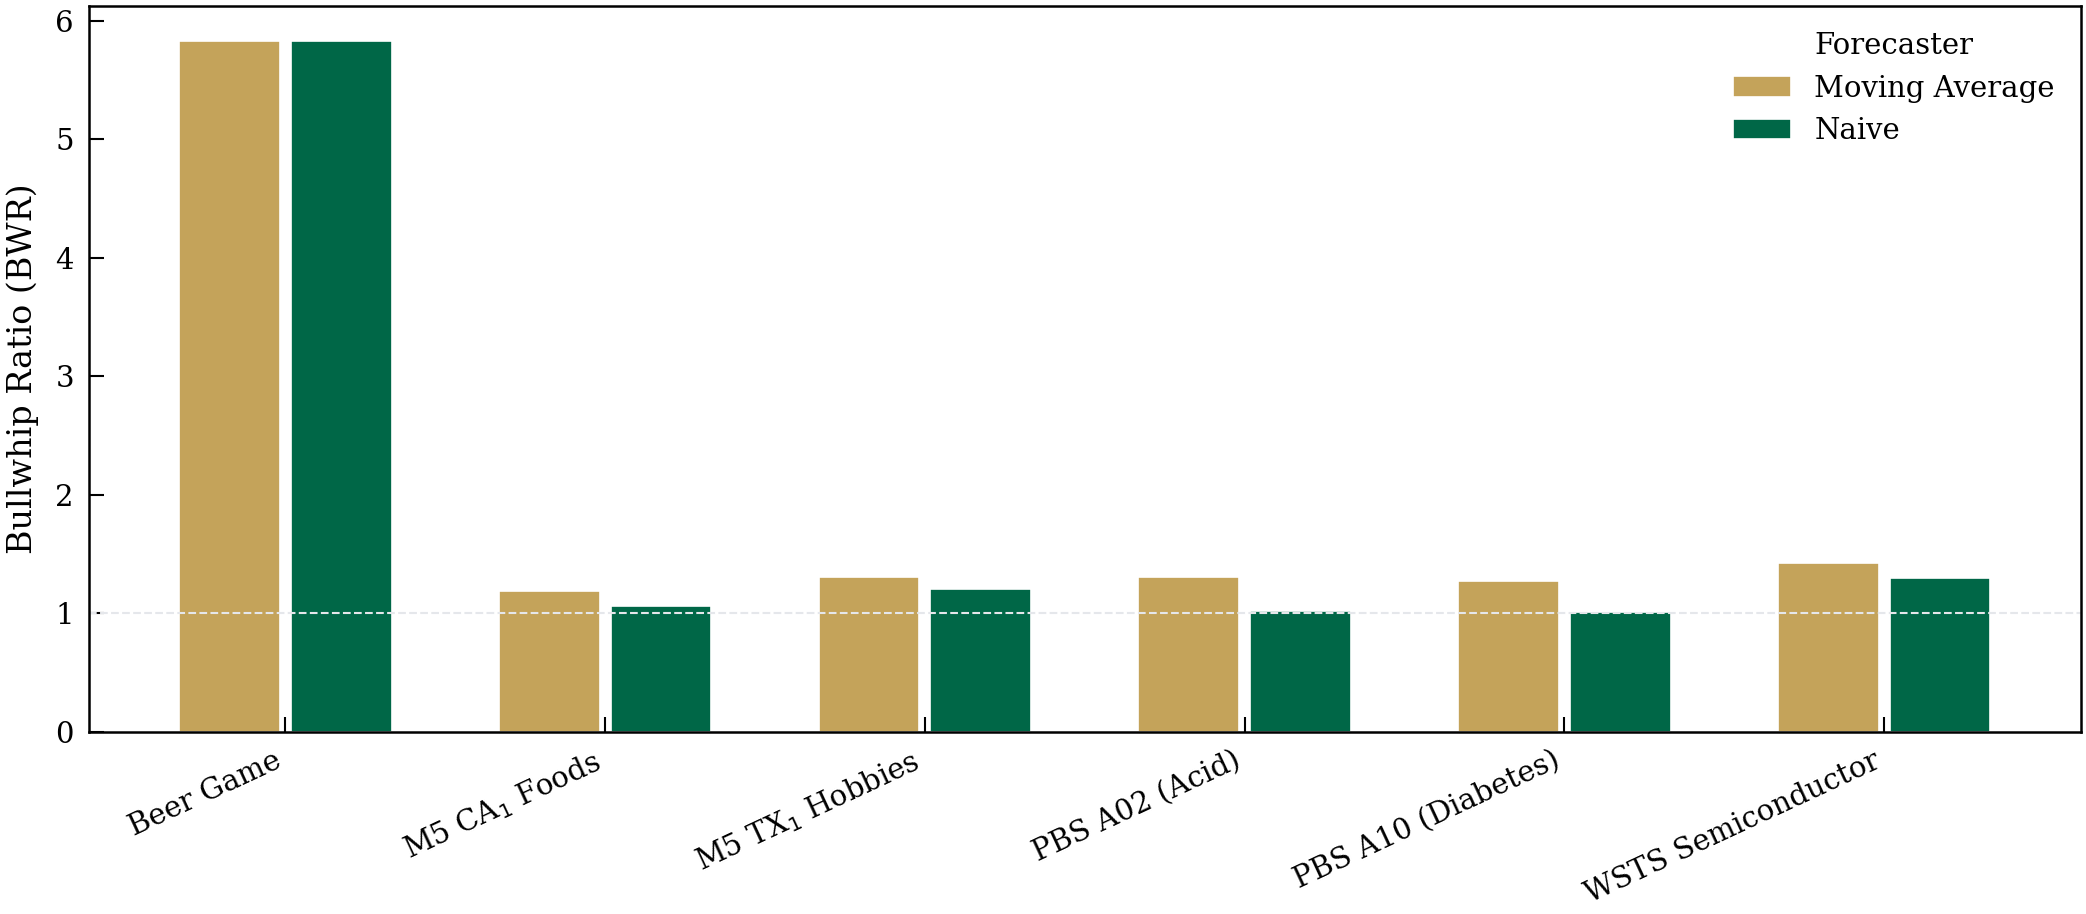

In [6]:
FC_COLORS_MAP = {"naive": COLORS["E1"], "moving_average": COLORS["E2"]}

fc_impact = results[
    (results["echelon"] == "E1") &
    (results["metric"] == "BWR") &
    (results["policy"] == "order_up_to")
].pivot_table(index="dataset", columns="forecaster", values="value")

fig, ax = plt.subplots(figsize=(DOUBLE_COL, DOUBLE_COL / GOLDEN / 1.4))

n_ds = len(fc_impact)
n_fc = len(fc_impact.columns)
x = np.arange(n_ds)
bar_w = 0.7 / n_fc

for i, fc_name in enumerate(fc_impact.columns):
    offset = (i - n_fc / 2 + 0.5) * bar_w
    color = FC_COLORS_MAP.get(fc_name, _ECHELON_COLORS[i])
    ax.bar(x + offset, fc_impact[fc_name], bar_w * 0.9,
           color=color, edgecolor="white", linewidth=0.4,
           label=fc_name.replace("_", " ").title())

ax.axhline(y=1.0, color=COLORS["grid"], linestyle="--", linewidth=0.5)
ax.set_ylabel("Bullwhip Ratio (BWR)")
ax.set_xticks(x)
ax.set_xticklabels(fc_impact.index, rotation=25, ha="right", fontsize=7)
ax.legend(frameon=False, fontsize=7, title="Forecaster", title_fontsize=7)

fig.savefig("forecaster_impact.pdf", dpi=300, bbox_inches="tight")
fig.savefig("forecaster_impact.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Export Results

In [7]:
# Export full results
results.to_csv("benchmark_real_datasets.csv", index=False)
print("Results saved to benchmark_real_datasets.csv")

# LaTeX table (E1, Naive forecaster)
from deepbullwhip.benchmark.report import to_latex

e1_naive = results[(results["echelon"] == "E1") & (results["forecaster"] == "naive")].copy()
# Add dataset to policy name for the pivot
e1_naive["policy_ds"] = e1_naive["dataset"].str[:10] + " / " + e1_naive["policy"]
latex = to_latex(e1_naive, caption="Bullwhip Benchmarks Across Real-World Datasets", label="tab:real-datasets")
print(latex[:500], "...")

Results saved to benchmark_real_datasets.csv
\begin{table}[htbp]
\centering
\caption{Bullwhip Benchmarks Across Real-World Datasets}
\label{tab:real-datasets}
\begin{tabular}{llrrr}
\toprule
 & metric & BWR & FILL_RATE & TC \\
policy & echelon &  &  &  \\
\midrule
constant_order & E1 & 0.000 & 0.989 & 34074156.052 \\
\cline{1-5}
order_up_to & E1 & 1.907 & 0.706 & 3860386.473 \\
\cline{1-5}
proportional_out & E1 & 1.799 & 0.205 & 7488392.976 \\
\cline{1-5}
\bottomrule
\end{tabular}

\end{table} ...
